# **Librerias y Funciones**


In [ ]:
#Instalación de la libreria que usaremos para calcular homología persistente via Vietoris-Rips
!pip install ripser

In [ ]:
#Importamos todas las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
import bisect
import math

from ripser import ripser
from persim import plot_diagrams
from persim import PersistenceImager

from mpl_toolkits  import  mplot3d

from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
#Funcion para aplicar el embedding de Takens
def takens_embedding(signal, tau, d):
     n = len(signal) - (d-1)*tau
     embedded = np.zeros((n, d))

     for i in range(0,d):
         embedded[:, i] = signal[i*tau : i*tau + n]
     return embedded

#Funcion para calcular Landscapes
def persistence_landscape(diag):
    diag.sort(key=lambda x: (x[0], -x[1]))

    L = []
    k = 0

    while len(diag) > 0:
        Lk = []
        b, d = diag.pop(0)

        Lk.extend([(float('-inf'), 0), (b, 0), ((b + d) / 2, (d - b) / 2)])


        while Lk[-1] != (float('inf'), 0):

            if not diag or d >= max((item[1] for item in diag), default=-float('inf')):
                Lk.extend([(d, 0), (float('inf'), 0)])
            else:

                idx_prime = -1
                for i, (bp, dp) in enumerate(diag):
                    if dp > d:
                        idx_prime = i
                        break

                b_prime, d_prime = diag.pop(idx_prime)

                if b_prime > d:
                    Lk.append((d, 0))

                if b_prime >= d:
                    Lk.append((b_prime, 0))
                else:
                    Lk.append(((b_prime + d) / 2, (d - b_prime) / 2))

                    new_item = (b_prime, d)

                    bisect.insort(diag, new_item, key=lambda x: (x[0], -x[1]))

                Lk.append(((b_prime + d_prime) / 2, (d_prime - b_prime) / 2))
                b, d = b_prime, d_prime

        L.append(Lk)
        k += 1

    return L

#Funcion para graficar el diagrama de persistencia
def graficar_diag(dgms, Titulo, guardado):
    fig, ax = plt.subplots(figsize=(7, 7))

    max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

    x_vals = np.linspace(0, max_val, 100)
    ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

    colors = ['#2AA58B', '#804C80', '#27ae60', '#c0392b']
    labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

    for i, dgm in enumerate(dgms):
        if dgm.size > 0:
            clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

            ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                      color=colors[i],
                      label=labels[i],
                      s=80,
                      alpha=0.8,
                      edgecolors='none')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlim(-0.03*max_val, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel('Nacimiento', fontsize=15)
    ax.set_ylabel('Muerte', fontsize=15)
    ax.set_title(f'{Titulo}', fontsize=15)
    ax.legend()
    plt.savefig(f'{guardado}', bbox_inches='tight')
    plt.show()

# **Importe de los Datos y Calculo de sus Diagramas de Persistencia**

In [ ]:
Rima_1 = '''
London Bridge is falling down,
Falling down, falling down,
London Bridge is falling down,
My fair Lady.

Build it up with wood and clay,
Wood and clay, wood and clay,
Build it up with wood and clay,
My fair Lady.

Wood and clay will wash away,
Wash away, wash away,
Wood and clay will wash away,
My fair Lady.

Build it up with bricks and mortar,
Bricks and mortar, bricks and mortar,
Build it up with bricks and mortar,
My fair Lady.

Bricks and mortar will not stay,
Will not stay, will not stay,
Bricks and mortar will not stay,
My fair Lady.

Build it up with iron and steel,
Iron and steel, iron and steel,
Build it up with iron and steel,
My fair Lady.

Iron and steel will bend and bow,
Bend and bow, bend and bow,
Iron and steel will bend and bow,
My fair Lady.

Build it up with silver and gold,
Silver and gold, silver and gold,
Build it up with silver and gold,
My fair Lady.

Silver and gold will be stolen away,
Stolen away, stolen away,
Silver and gold will be stolen away,
My fair Lady.

Set a man to watch all nigh,
Watch all night, watch all night,
Set a man to watch all night,
My fair Lady.

Suppose the man should fall asleep,
Fall asleep, fall asleep,
Suppose the man should fall asleep?
My fair Lady.

Give him a pipe to smoke all night,
Smoke all night, smoke all night,
Give him a pipe to smoke all night,
My fair Lady.
'''

Rima_2 = '''
Do you know the muffin man,
The muffin man, the muffin man,
Do you know the muffin man,
Who lives in Drury Lane?

Yes, I know the muffin man,
The muffin man, the muffin man,
Yes, I know the muffin man,
Who lives in Drury Lane.
'''
Rima_3 = '''
The itsy bitsy spider crawled up the water spout.
Down came the rain, and washed the spider out.
Out came the sun, and dried up all the rain,
and the itsy bitsy spider went up the spout again
'''

Rima_4 = '''
Mary had a little lamb,
whose fleece was white as snow.

And everywhere that Mary went,
the lamb was sure to go.

It followed her to school one day
which was against the rules.

It made the children laugh and play,
to see a lamb at school.

And so the teacher turned it out,
but still it lingered near,

And waited patiently about,
till Mary did appear.
'''

Rima_5 = '''
The wheels on the bus go round and round
Round and round, round and round
The wheels on the bus go round and round
All through the town

The wipers on the bus go “Swish, swish, swish,
Swish, swish, swish, swish, swish, swish”
The wipers on the bus go “Swish, swish, swish”
All through the town.

The people on the bus go, “chat, chat, chat,
cha,,chat chat,chat chat ,chat
The people on the bus go, “, chat,chat,chat
All through the town.

The horn on the bus go “Beep, beep, beep
Beep, beep, beep, beep, beep, beep”
The horn on the bus go “Beep, beep, beep”
All through the town.

The baby on the bus go, “wah, wah, wah!
wah, wah, wah, wah, wah, wah!”
The baby on the bus go, “wah, wah, wah!”
All through the town.

The mummy on the bus go, “ssss sh,ssss sh,ssss sh,
“ ”ssss sh,ssss sh,ssss sh"
The mummy on the bus go,
All through the town.

The wheels on the bus go round and round
Round and round, round and round
The wheels on the bus go round and round
All through the town.
'''

Rima_6 = '''
Five little monkeys jumping on the bed.
One fell off and bumped his head.
Mama called the doctor and the doctor said,
“No more monkeys jumping on the bed!”

Four little monkeys jumping on the bed.
One fell off and bumped his head.
Mama called the doctor and the doctor said,
“No more monkeys jumping on the bed!”

Three little monkeys jumping on the bed.
One fell off and bumped her head.
Mama called the doctor and the doctor said,
“No more monkeys jumping on the bed!”

Two little monkeys jumping on the bed.
One fell off and bumped his head.
Mama called the doctor and the doctor said,
“No more monkeys jumping on the bed!”

One little monkey jumping on the bed.
She fell off and bumped her head.
Mama called the doctor and the doctor said,
“No more monkeys jumping on the bed!”
'''

Rima_7 = '''
Eeny, meeny, miny, moe
Catch a tiger by the toe
If he hollers let him go,
Eeny, meeny, miny, moe
My mother told me
To pick the very best one
And you are it
'''

Rima_8 = '''
Baa, baa, black sheep,
Have you any wool?
Yes sir, yes sir,
Three bags full.
One for the master,
One for the dame,
And one for the little boy
Who lives down the lane
'''

Rima_9 = '''
Old King Cole was a merry old soul, and a merry old soul was he;
He called for his pipe in the middle of the night
And he called for his fiddlers three.
Every fiddler had a fine fiddle, and a very fine fiddle had he;
Oh there's none so rare as can compare
With King Cole and his fiddlers three
'''

Rima_10 = '''
Sing a song of sixpence a pocket full of rye,
Four and twenty blackbirds baked in a pie.
When the pie was opened the birds began to sing,
Oh wasn't that a dainty dish to set before the king?
The king was in his counting house counting out his money,
The queen was in the parlour eating bread and honey
The maid was in the garden hanging out the clothes,
When down came a blackbird and pecked off her nose!
'''

texto_1 = '''
Coeliac disease is a chronic,
autoimmune disease mainly affecting the small intestine,
caused by an abnormal immune system response to gluten.
'''

texto_2 = '''
The Indigenous Peoples' Center for Documentation, Research and Information (Docip) is a Swiss non-profit,
non-governmental organisation supporting Indigenous peoples in defending their rights,
primarily by working with the United Nations and European institutions.
'''

texto_3 = '''
Paper Rex moved into Valorant with their first roster on 19 July 2020,
acquiring members of the Singaporean team Vindicta.
'''

texto_4 = '''
The Trojan War was a legendary conflict in Greek mythology that took place around the twelfth or thirteenth century BC.
'''

texto_5 = '''
Park Lane is a Tyne and Wear Metro station, serving the port city of Sunderland in Tyne and Wear, England.
It joined the network on 28 April 2002, following the opening of the extension from Pelaw to South Hylton.
'''

texto_6 = '''
OpenPsych is an online collection of three pseudoscientific open access journals covering behavioral genetics, psychology, and quantitative research in sociology.
'''

texto_7 = '''
Colloidal sulphur, better known as the brand name Sulfosin or one of its spelling variants,
is a pharmaceutical drug originally used for its ability to causes a pyrogenic reaction
'''

texto_8 = '''
The prime minister of the Bahamas is the head of government of the Bahamas.
The prime minister is formally appointed into office by the governor-general of the Bahamas,
who represents Charles III, the king of the Bahamas.
'''

texto_9 = '''
In telecommunications, Structured cabling is the design and installation of a complete,
standards-compliant telecommunications cabling infrastructure for building, platform, factory or campus cabling infrastructure.
'''

texto_10 = '''
A defeater of a belief is evidence that this belief is false.
 Defeaters are of particular interest to epistemology because they affect whether a belief is justified.
'''

In [ ]:
#documentos
documentos = [Rima_1, Rima_2, Rima_3, Rima_4, Rima_5, Rima_6, Rima_7, Rima_8, Rima_9, Rima_10, texto_1, texto_2, texto_3, texto_4, texto_5, texto_6, texto_7, texto_8, texto_9, texto_10]

#Nombres para cada dato
nombres = [r'$R_1$', r'$R_2$', r'$R_3$', r'$R_4$', r'$R_5$', r'$R_6$', r'$R_7$', r'$R_8$', r'$R_9$', r'$R_{10}$', r'$T_1$', r'$T_2$', r'$T_3$', r'$T_4$', r'$T_5$', r'$T_6$', r'$T_7$', r'$T_8$', r'$T_9$', r'$T_{10}$']

#Categorias de los datos
tipo_dato=['Rimas','Wikipedia']

#Número de elementos por categoria
elem_tipo=10



#Título para las gráficas
titulo="Rimas infantiles vs Wikipedia"

#Colores para las gráficas
colores = ['#603160', '#D49AD4', '#2AA58B', '#AEEEE2']

#Etiquetas para las gráficas
etiquetas=[]
for i in range(len(tipo_dato)):
    etiquetas=etiquetas+list([tipo_dato[i]]*elem_tipo)


In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

#Definir hiperparámetros:
language = 'english'  # Idioma
remove_stopwords = True  # Quitamos palabras vacías (the, and, etc.)
max_length = 50  # Longitud máxima de la secuencia de palabras

#Limpiamos los documentos
if remove_stopwords:
    stop_words = set(stopwords.words(language))
    documentos_limpios = [" ".join([word for word in word_tokenize(doc.lower()) if word not in stop_words]) for doc in documentos]
print(f"Documentos limpios:\n{documentos_limpios}\n")

#Vectorización:
vectorizador = TfidfVectorizer()

#Diccionario de palabras e índices
vectorizador.fit(documentos_limpios)
words_to_idxs = vectorizador.vocabulary_
print(f"Diccionario del vocabulario:\n{words_to_idxs}\n")

#convertimos los documentos en una secuencia de escalares
def text_to_sequence(text, max_length=20):
    vector = np.zeros(max_length)
    text = text.lower()
    words = word_tokenize(text)
    words = words[:max_length]
    for j,word in enumerate(words):
        if word in words_to_idxs.keys():
            vector[j] = words_to_idxs[word]
    return vector
secuencias = np.zeros((len(documentos), max_length))
for j,doc in enumerate(documentos_limpios):
    v = text_to_sequence(doc,max_length)
    secuencias[j] = v
    print(f"Texto: {doc}\nVector: {v}\n")
print(f"Matriz de secuencias:\n{secuencias}")

#Re-escalar secuencias
escalador = MinMaxScaler()
secuencias_escaladas = escalador.fit_transform(secuencias.T).T
print(f"Secuencias escaladas:\n{secuencias_escaladas}")

#Conjunto de datos finales
Datos = secuencias_escaladas.copy()

Documentos limpios:
['london bridge falling , falling , falling , london bridge falling , fair lady . build wood clay , wood clay , wood clay , build wood clay , fair lady . wood clay wash away , wash away , wash away , wood clay wash away , fair lady . build bricks mortar , bricks mortar , bricks mortar , build bricks mortar , fair lady . bricks mortar stay , stay , stay , bricks mortar stay , fair lady . build iron steel , iron steel , iron steel , build iron steel , fair lady . iron steel bend bow , bend bow , bend bow , iron steel bend bow , fair lady . build silver gold , silver gold , silver gold , build silver gold , fair lady . silver gold stolen away , stolen away , stolen away , silver gold stolen away , fair lady . set man watch nigh , watch night , watch night , set man watch night , fair lady . suppose man fall asleep , fall asleep , fall asleep , suppose man fall asleep ? fair lady . give pipe smoke night , smoke night , smoke night , give pipe smoke night , fair lady .',

In [ ]:
Datos[11]

array([0.42105263, 0.66563467, 0.        , 0.16408669, 0.26315789,
       0.        , 0.73374613, 0.42414861, 0.        , 0.25696594,
       0.        , 0.87616099, 0.        , 0.        , 0.        ,
       0.63467492, 0.86377709, 0.42105263, 0.66563467, 0.24458204,
       0.74303406, 0.        , 0.69659443, 1.        , 0.93498452,
       0.58204334, 0.2879257 , 0.43343653, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [ ]:
Datos[10]

array([0.22183099, 0.28521127, 0.20774648, 0.        , 0.0528169 ,
       0.28521127, 0.58098592, 0.03169014, 0.90492958, 0.5       ,
       0.        , 0.17957746, 0.01760563, 0.47535211, 1.        ,
       0.83802817, 0.42253521, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [ ]:
diagramas_persistencia=[]
embeddings_takens=[]
puntos=[]
for i in range(0,len(Datos)):
    #Calcular embedding de Takens
    matriz_takens=takens_embedding(Datos[i],1,2)
    embeddings_takens.append(matriz_takens)

    #Agregar coordenada de conteo
    matriz_digitos=np.zeros((max_length-1,))
    for i in range(0,max_length-1):
        matriz_digitos[i]=i

    matriz_digitos=matriz_digitos[:, np.newaxis]
    matriz_puntos=np.concatenate((matriz_digitos, matriz_takens),axis=1)
    puntos.append(matriz_puntos)

    #Calcular Diagramas de Persistencia
    diagramas_persistencia.append(ripser(matriz_puntos, maxdim=1)['dgms'])

# **Visualización de Datos y Diagramas**

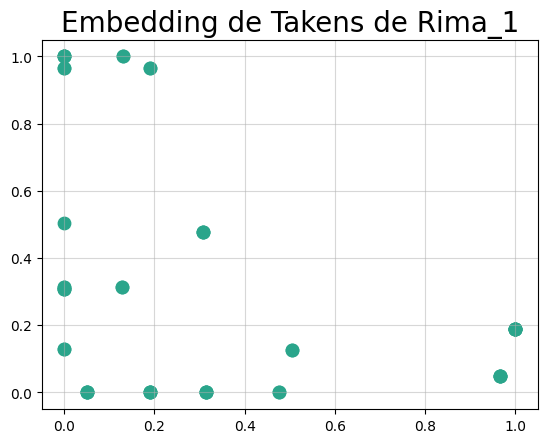

In [ ]:
plt.figure()
plt.scatter(embeddings_takens[0][:,0], embeddings_takens[0][:,1], color='#2AA58B', s=80)
plt.title(r"Embedding de Takens de Rima_1", fontsize=20)
plt.grid(True, alpha=0.5)
plt.show()

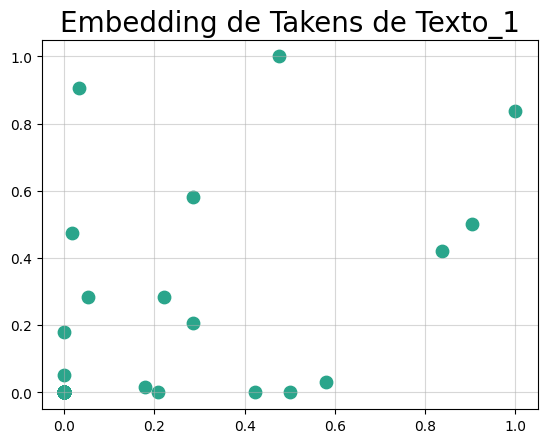

In [ ]:
plt.figure()
plt.scatter(embeddings_takens[10][:,0], embeddings_takens[10][:,1], color='#2AA58B', s=80)
plt.title(r"Embedding de Takens de Texto_1", fontsize=20)
plt.grid(True, alpha=0.5)
plt.show()

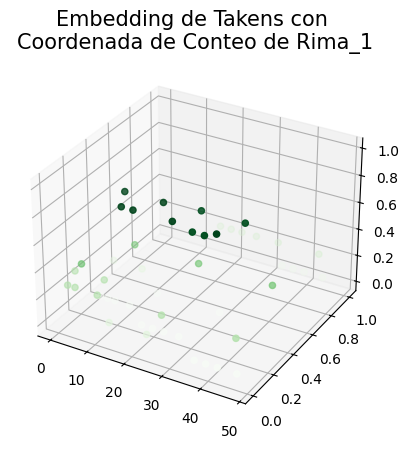

In [ ]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.scatter3D (puntos[0][:,0],  puntos[0][:,1],  puntos[0][:,2],  c=puntos[0][:,2], cmap = 'Greens')
plt.title("Embedding de Takens con \n"+r"Coordenada de Conteo de Rima_1", fontsize=15)
plt.show()

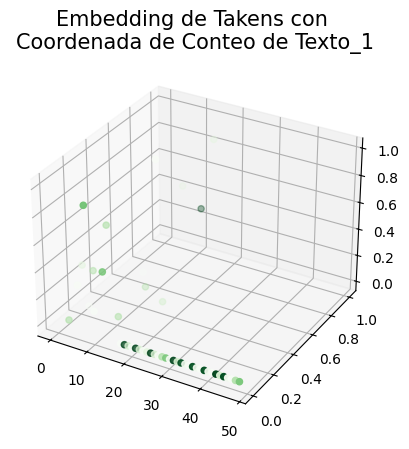

In [ ]:
fig = plt.figure( )
ax = plt.axes(projection='3d')
ax.scatter3D (puntos[10][:,0],  puntos[10][:,1],  puntos[10][:,2],  c=puntos[0][:,2], cmap = 'Greens')
plt.title("Embedding de Takens con \n"+r"Coordenada de Conteo de Texto_1", fontsize=15)
plt.show()

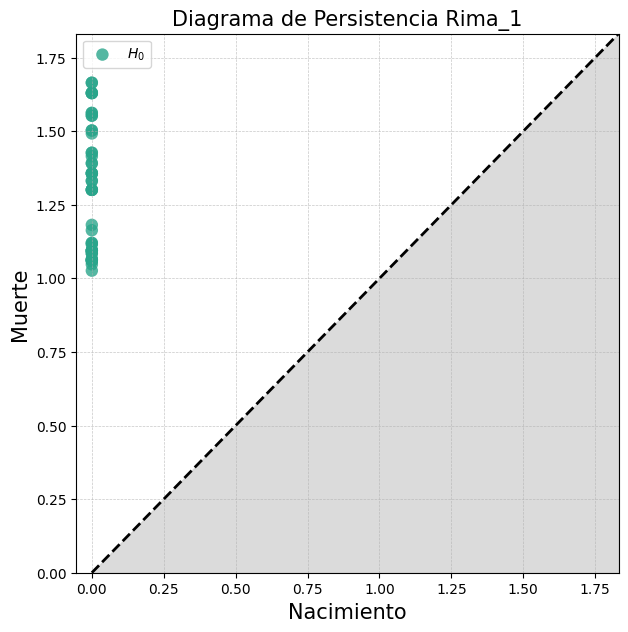

In [ ]:
graficar_diag(diagramas_persistencia[0], Titulo=r'Diagrama de Persistencia Rima_1', guardado='Diagrama de Persistencia Rima_1')

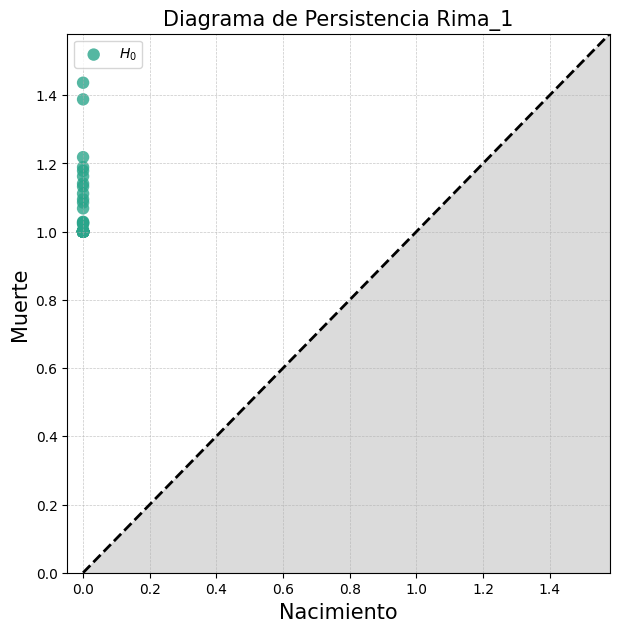

In [ ]:
graficar_diag(diagramas_persistencia[10], Titulo=r'Diagrama de Persistencia Rima_1', guardado='Diagrama de Persistencia Rima_1')

# **Concatenacion**

In [ ]:
#Calcular vectorización mediante concatenación
concatenacion_planos=[]
for j in range(len(Datos)):
  if diagramas_persistencia[j][0].tolist()!=[]:
    concatenacion_planos.append(diagramas_persistencia[j][0][0:-1].flatten())
  else:
    concatenacion_planos.append([])

In [ ]:
#Aplicar Padding
dimensiones_concatenacion=[]
for j in range(len(Datos)):
  dimensiones_concatenacion.append(len(concatenacion_planos[j]))

concatenacion_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones_concatenacion)-len(concatenacion_planos[j]))
  concatenacion_planos_padding.append(np.concatenate((concatenacion_planos[j], ceros)))

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(concatenacion_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.33271852356979126


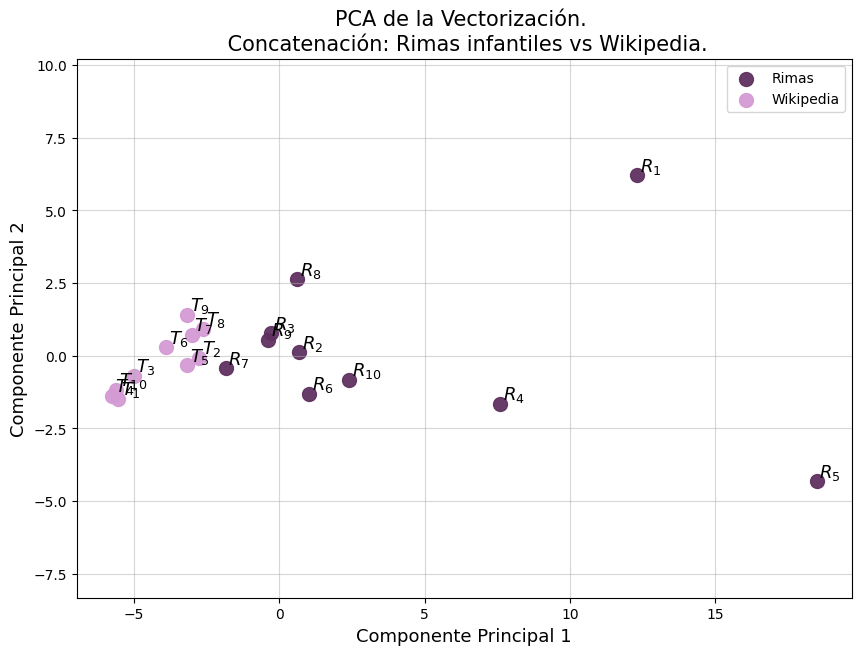

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(concatenacion_planos_padding)

concatenacion_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(concatenacion_pca[:,0][inicio:fin], concatenacion_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(concatenacion_pca[:,0])):
    plt.annotate(nombres[i], (concatenacion_pca[:,0][i], concatenacion_pca[:,1][i]), xytext=(2, 3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de la Vectorización. \n Concatenación: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Concatenacion_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

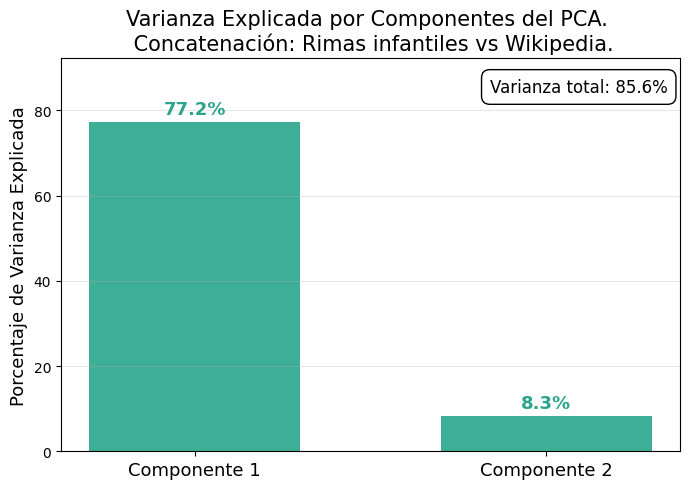

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Concatenación: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=12,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

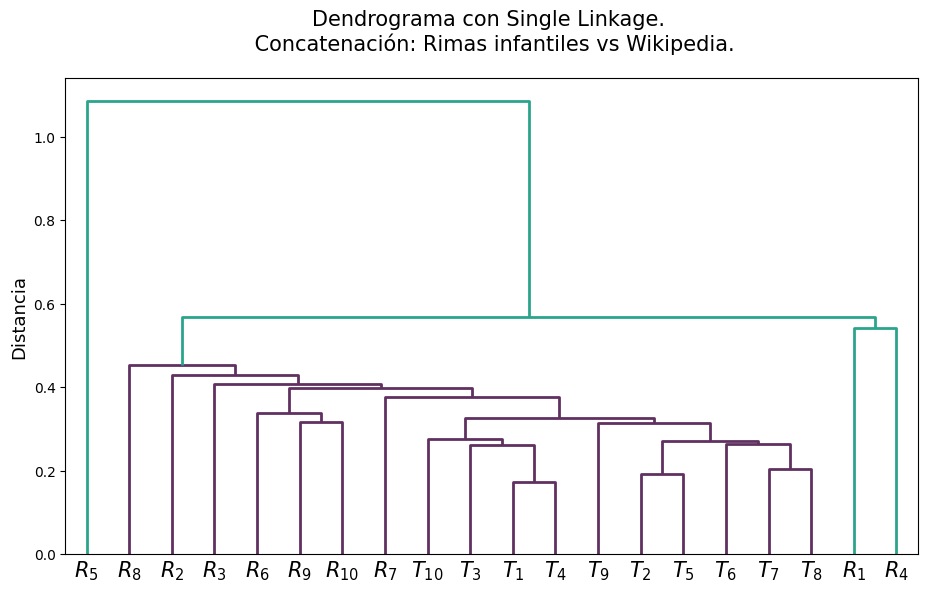

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(concatenacion_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 0.5
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

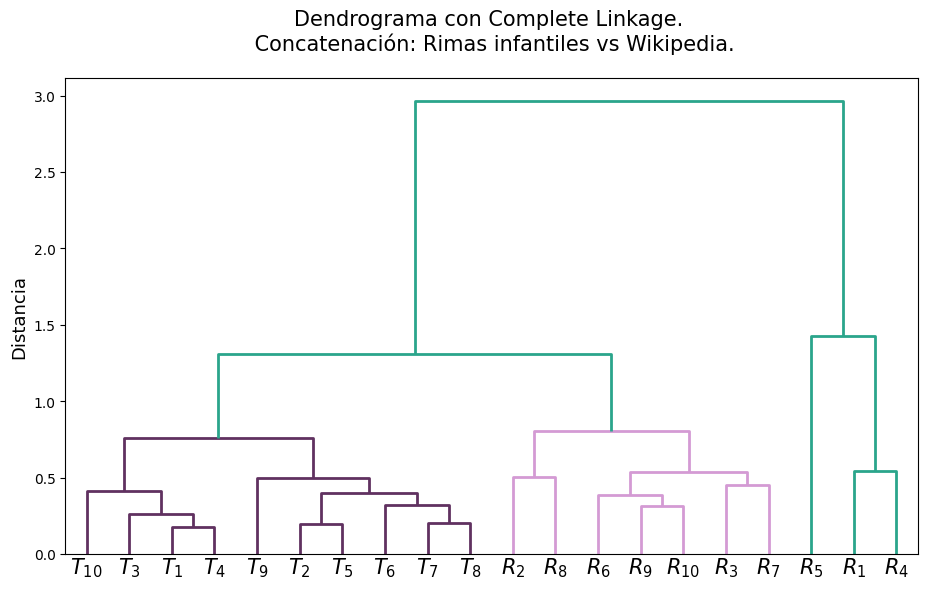

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(concatenacion_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 1
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

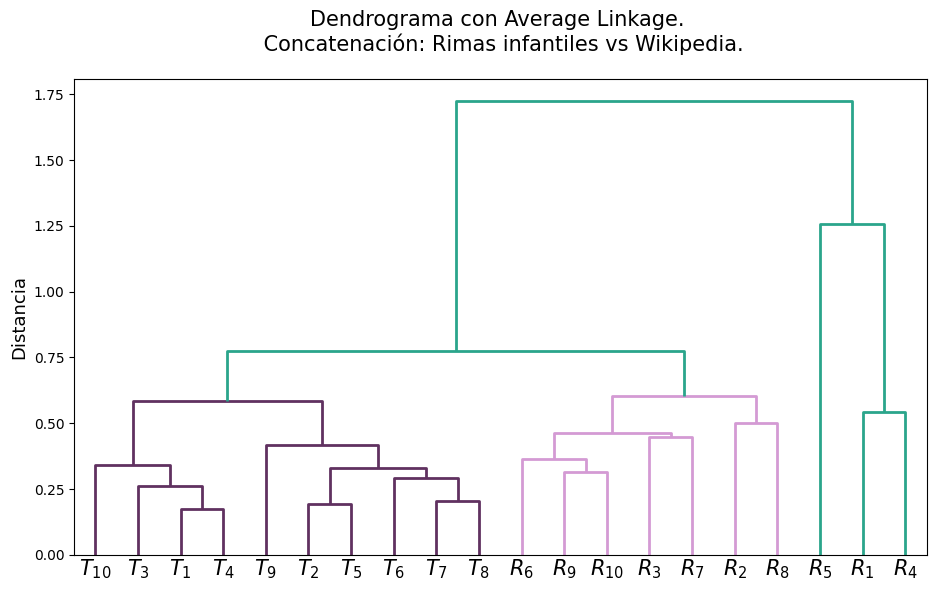

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(concatenacion_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 0.7
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Concatenación: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Concatenación {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Landscapes**

In [ ]:
#Calcular vectorización mediante landscapes
landscapes=[]

for j in range(len(Datos)):
    aux=diagramas_persistencia[j][0][0:-1].tolist()

    if aux!=[]:
      landscapes.append(persistence_landscape(aux))
    else:
      landscapes.append([])

In [ ]:
#Aplanar landscapes
landscapes_planos=[]
for j in range(len(Datos)):

  if landscapes[j]!=[]:
    aux=landscapes[j][0]
    for i in range(1,len(landscapes[j])):
      aux=np.concatenate((aux, landscapes[j][i]))

    aux=[p for p in aux if not math.isinf(p[0])]
    landscapes_planos.append(aux)
  else:
    landscapes_planos.append((0,0))

  landscapes_planos[j]=np.array(landscapes_planos[j]).flatten()

In [ ]:
#Aplicar Padding
dimensiones=[]
for j in range(len(Datos)):
  dimensiones.append(len(landscapes_planos[j]))

landscapes_planos_padding=[]

for j in range(len(Datos)):
  ceros=np.zeros(max(dimensiones)-len(landscapes_planos[j]))
  landscapes_planos_padding.append(np.concatenate((landscapes_planos[j], ceros)))

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(landscapes_planos_padding, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.3327185235697997


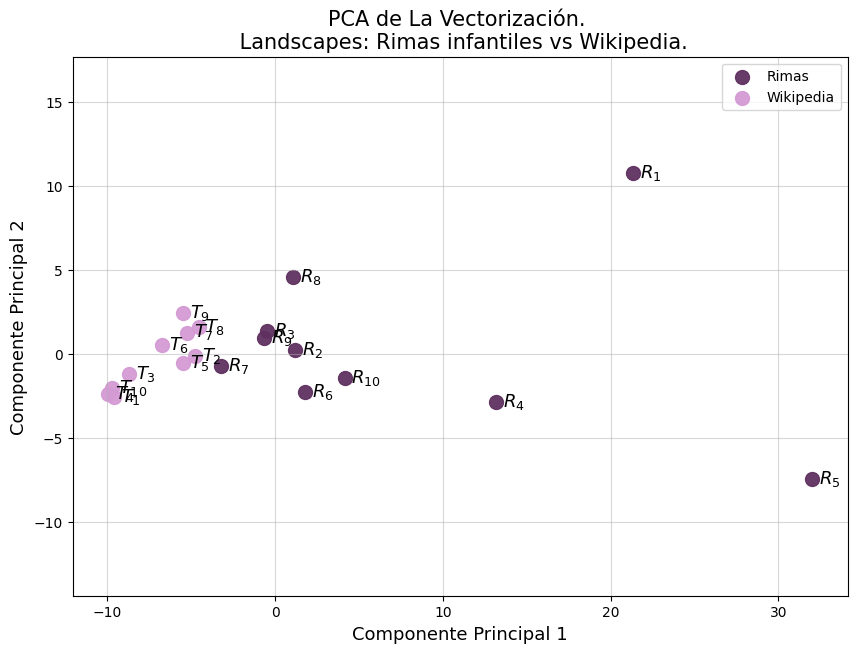

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(landscapes_planos_padding)

landscapes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(landscapes_pca[:,0][inicio:fin], landscapes_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(landscapes_pca[:,0])):
    plt.annotate(nombres[i], (landscapes_pca[:,0][i], landscapes_pca[:,1][i]), xytext=(5, -3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de La Vectorización. \n Landscapes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Landscapes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.axis('equal')
plt.show()

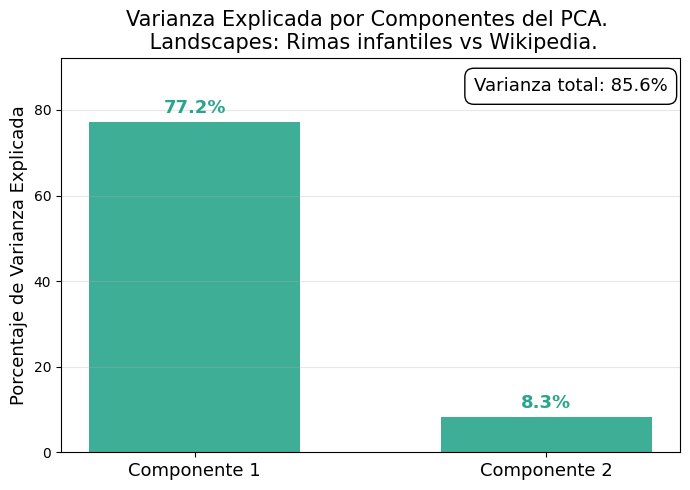

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Landscapes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=13,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

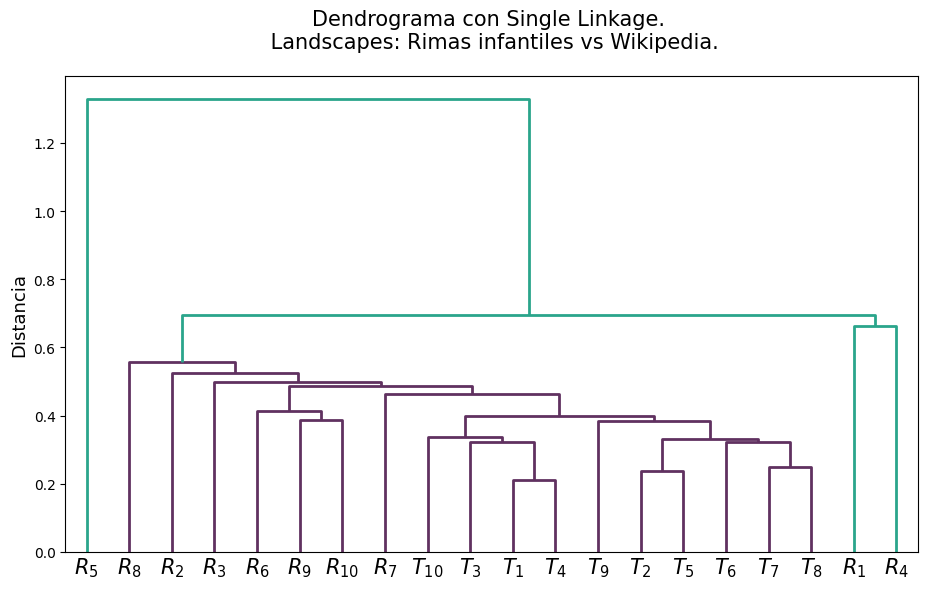

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(landscapes_planos_padding, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.6
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

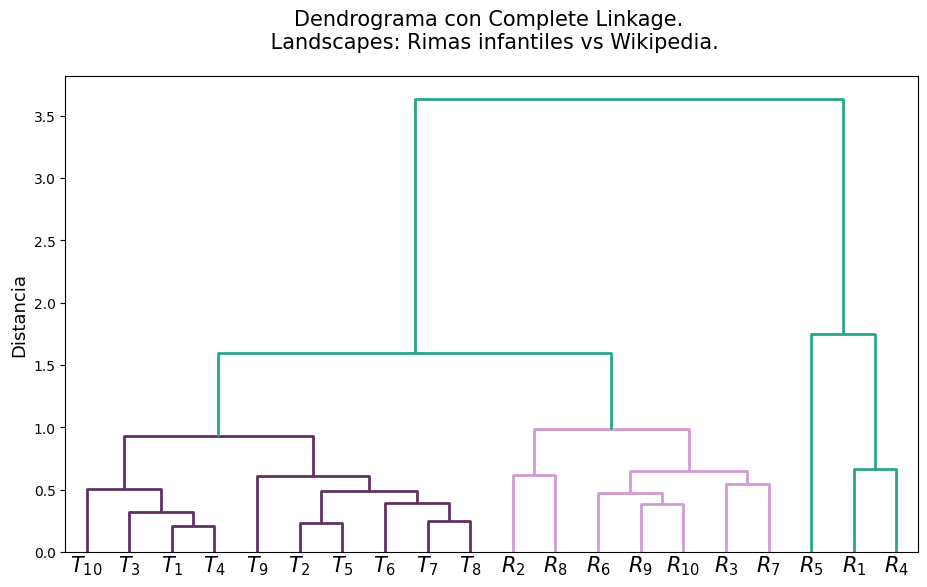

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(landscapes_planos_padding, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 1
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

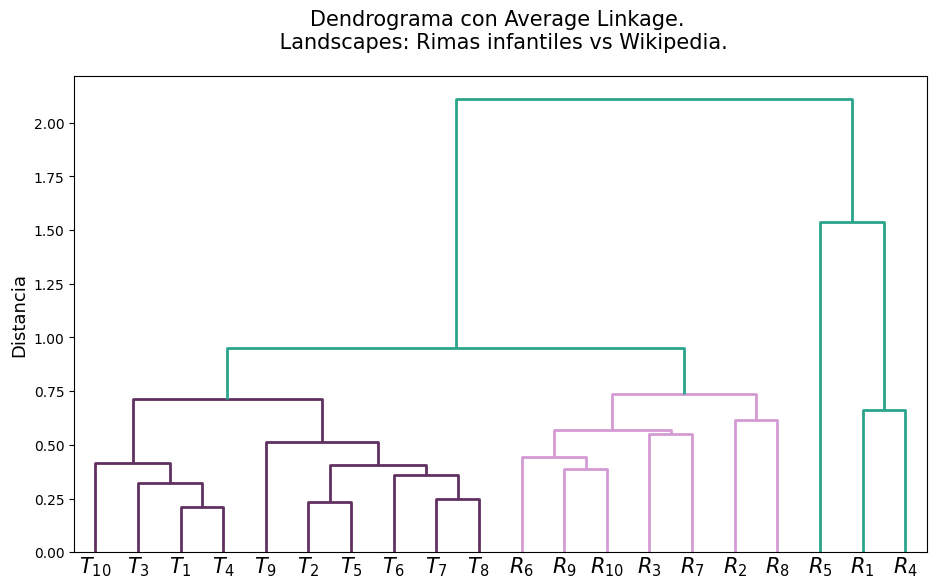

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(landscapes_planos_padding, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

nombres_a_rotar = {'Liouville', 'Champernowne'}

plt.figure(figsize=(11, 7))

umbral_manual = 0.8
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.01

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Landscapes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Landscapes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

# **Imagenes Persistentes**

In [ ]:
#Calcular vectorización mediante imágenes persistentes
imagenes_persistencia=[]
for j in range(0,len(Datos)):
    pimgr = PersistenceImager()
    pimgr.birth_range = (0, 12)
    pimgr.pers_range = (0, 10)
    pimgr.kernel_params = {'sigma': 5.0}
    imagenes_persistencia.append(pimgr.transform(diagramas_persistencia[j][0][0:-1]))


In [ ]:
#Aplanar imágenes persistentes
imagenes_planas=[]
for j in range(0,len(Datos)):
  imagenes_planas.append(imagenes_persistencia[j].flatten())

imagenes_planas=np.array(imagenes_planas)

In [ ]:
#Coeficiente de silueta natural
score = silhouette_score(imagenes_planas, etiquetas)
print(f"Coeficiente de silueta natural: {score}")

Coeficiente de silueta natural: 0.44038579680960377


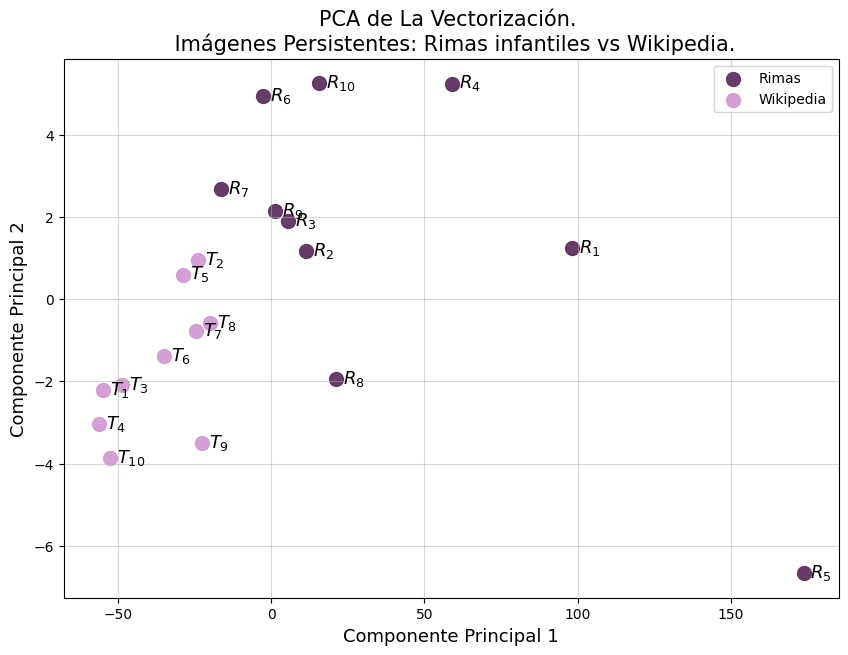

In [ ]:
#Aplicar PCA de dimensión dos para visualizar los datos
pca=PCA(n_components=2)

X_scaled = StandardScaler().fit_transform(imagenes_planas)

imagenes_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for i in range(len(tipo_dato)):
    inicio, fin = i*elem_tipo, (i+1)*elem_tipo
    plt.scatter(imagenes_pca[:,0][inicio:fin], imagenes_pca[:,1][inicio:fin], c=colores[i], label=tipo_dato[i], s=100, alpha=0.95)

for i in range(len(imagenes_pca[:,0])):
    plt.annotate(nombres[i], (imagenes_pca[:,0][i], imagenes_pca[:,1][i]), xytext=(5, -3), textcoords="offset points", ha='left',fontsize=13)

plt.title(f"PCA de La Vectorización. \n Imágenes Persistentes: {titulo}.", fontsize=15)
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlabel(r"Componente Principal 1", fontsize=13)
plt.ylabel(r"Componente Principal 2", fontsize=13)
plt.savefig(f"PCA_Imagenes_Persistentes_{titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

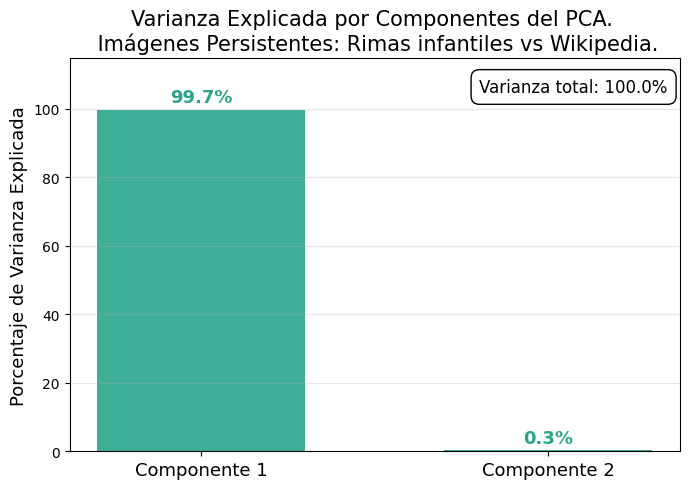

In [ ]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2], ['Componente 1', 'Componente 2'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA. \n Imágenes Persistentes: {titulo}.', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=12,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))


plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

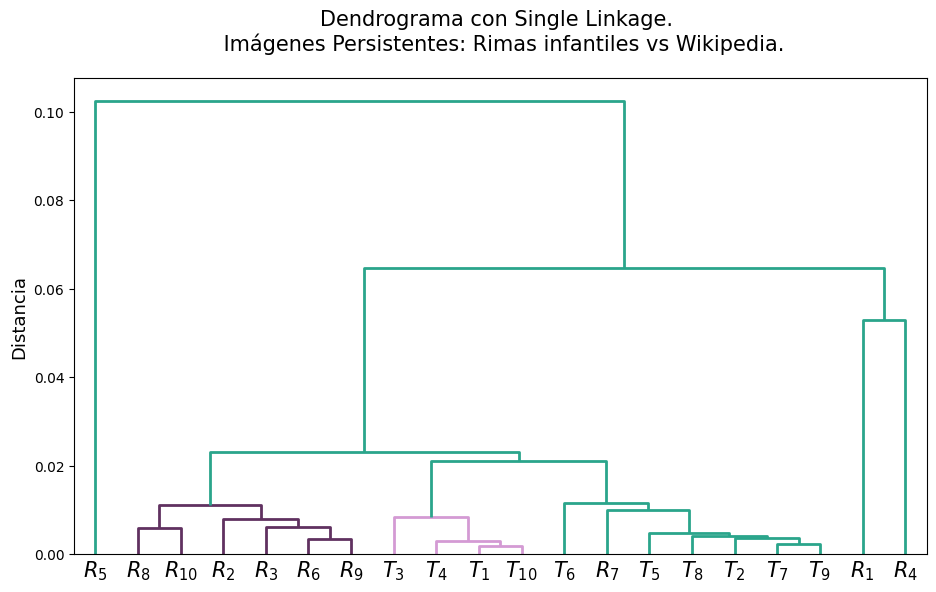

In [ ]:
#Calcular el dendrograma single linkage de la vectorización
Z_S = linkage(imagenes_planas, method='single', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 0.02
color_final = colores[2]

dendro = dendrogram(Z_S, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.001

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Single Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Single Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

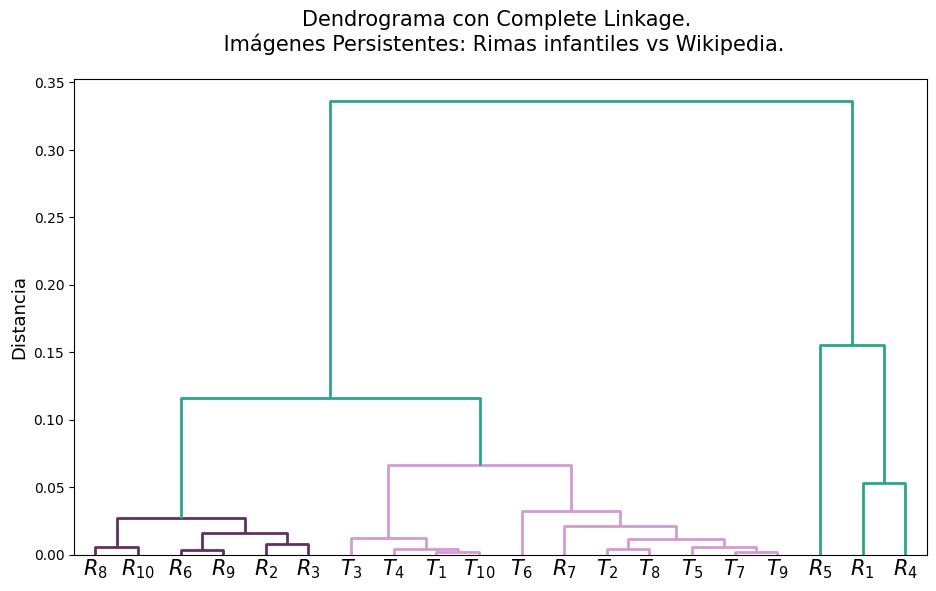

In [ ]:
#Calcular el dendrograma complete linkage de la vectorización
Z_C = linkage(imagenes_planas, method='complete', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 0.08
color_final = colores[2]

dendro = dendrogram(Z_C, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.002

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Complete Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Complete Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()

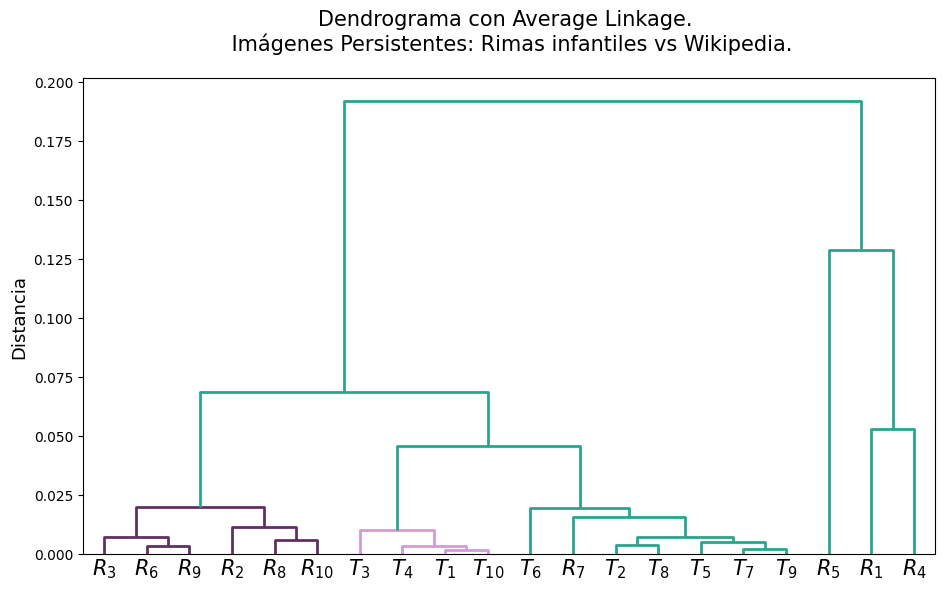

In [ ]:
#Calcular el dendrograma average linkage de la vectorización
Z_A = linkage(imagenes_planas, method='average', metric='euclidean')

set_link_color_palette(colores)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(11, 7))

umbral_manual = 0.03
color_final = colores[2]

dendro = dendrogram(Z_A, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)

icoord = np.array(dendro['icoord'])
dcoord = np.array(dendro['dcoord'])
leaves_x = sorted(icoord[dcoord == 0])
leaf_indices = dendro['leaves']
y_offset = -0.001

ax = plt.gca()
for x, idx in zip(leaves_x, leaf_indices):
    nombre_raw = nombres[idx]
    ax.text(x, y_offset, nombre_raw, rotation=0, ha='center', va='top', fontsize=15)


plt.title(f'Dendrograma con Average Linkage. \n Imágenes Persistentes: {titulo}.', fontsize=15, pad=20)
plt.ylabel('Distancia', fontsize=13)

plt.xticks([])
plt.subplots_adjust(bottom=0.2)

plt.savefig(f"Dendrograma Average Linkage Imagenes Persistentes {titulo}.png", dpi=300, bbox_inches='tight')
plt.show()